# 04 — Kaggle Tech Layoffs

**Goal:** Perform exploratory data analysis (EDA) to uncover patterns in layoffs, specifically:
* How has the number of layoffs change throughout the years in the US? In CA?
* Are more layoffs observed in particular months?
* Which industries are most affected by layoffs?
* Do factors, like company size and region, affect layoffs?

**Time window:** 2020-2025

## Imports

In [85]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

## Build dataframe

In [86]:
# load in data
kaggle_fn = os.path.join(os.getcwd(), "data", "raw", "kaggle", "Cleaned_tech_layoffs.csv")
df = pd.read_csv(kaggle_fn)

# quick look
df.head(10)

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862
5,6,Flytedesk,Boulder,other,Colorado,USA,North America,4.0,2020-03-18,20.0,20.0,16.0,Marketing,Seed,4.0,2020,40.014986,-105.270545
6,7,Remote Year,Chicago,other,Illinois,USA,North America,50.0,2020-03-19,50.0,100.0,50.0,Travel,Series B,17.0,2020,41.875562,-87.624421
7,8,CTO.ai,Vancouver,Cascadia,British Columbia,Canada,North America,30.0,2020-03-20,50.0,60.0,30.0,Infrastructure,Seed,7.0,2020,49.260872,-123.113952
8,9,Flywheel Sports,New York City,other,New York,USA,North America,784.0,2020-03-20,98.0,800.0,16.0,Fitness,Acquired,120.0,2020,40.712728,-74.006015
9,10,Compass,New York City,other,New York,USA,North America,375.0,2020-03-23,15.0,2500.0,2125.0,Real Estate,Series G,1600.0,2020,40.712728,-74.006015


In [87]:
# remove unnecessary columns
df = df.drop(columns=['Nr'])

In [88]:
# subset rows where Country is 'USA'
usa_df = df[df['Country'] == 'USA'].copy()
usa_df.head()

,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


## Preprocessing

### 1. Summarize the dataset

In [94]:
# display df structure
usa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1121 entries, 0 to 1743
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      1121 non-null   object 
 1   Location_HQ                  1121 non-null   object 
 2   Region                       1121 non-null   object 
 3   USState                      1121 non-null   object 
 4   Country                      1121 non-null   object 
 5   Continent                    1121 non-null   object 
 6   Laid_Off                     1121 non-null   float64
 7   Date_layoffs                 1121 non-null   object 
 8   Percentage                   1121 non-null   float64
 9   Company_Size_before_Layoffs  1121 non-null   float64
 10  Company_Size_after_layoffs   1121 non-null   float64
 11  Industry                     1121 non-null   object 
 12  Stage                        1105 non-null   object 
 13  Money_Raised_in__mil   

In [95]:
# display summary stats
usa_df.describe(include='all')

,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
count,1121,1121,1121,1121,1121,1121,1121.000000,1121,1121.000000,1121.000000,1121.000000,1121,1105,1057.000000,1121.000000,1121.000000,1121.000000
unique,829,92,3,34,1,1,NaN,573,NaN,NaN,NaN,49,15,NaN,NaN,NaN,NaN
top,Chegg,San Francisco,other,California,USA,North America,NaN,2020-04-02,NaN,NaN,NaN,Finance,Post-IPO,NaN,NaN,NaN,NaN
freq,6,305,560,570,1121,1121,NaN,13,NaN,NaN,NaN,132,345,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,379.181980,NaN,21.264050,5363.416592,4984.234612,NaN,NaN,899.323557,2022.307761,38.962931,-104.782063
std,NaN,NaN,NaN,NaN,NaN,NaN,1342.657077,NaN,21.579611,27256.144877,26347.495569,NaN,NaN,5740.581252,1.463491,3.675199,21.585952
min,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,0.000000,6.000000,0.000000,NaN,NaN,1.000000,2020.000000,25.774173,-123.262044
25%,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,8.000000,241.000000,176.000000,NaN,NaN,75.000000,2022.000000,37.496904,-122.419329
50%,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,15.000000,667.000000,546.000000,NaN,NaN,215.000000,2022.000000,37.779259,-121.563172
75%,NaN,NaN,NaN,NaN,NaN,NaN,230.000000,NaN,25.000000,1857.000000,1567.000000,NaN,NaN,496.000000,2023.000000,40.712728,-75.163526


In [96]:
# convert date features for seasonal analysis
usa_df['Date_layoffs'] = pd.to_datetime(usa_df['Date_layoffs'])
usa_df['Month'] = usa_df['Date_layoffs'].dt.month
usa_df['Month_Name'] = usa_df['Date_layoffs'].dt.month_name()

* The dataset contains information on worldwide layoffs in tech companies between 2020 and 2025. We have decided to concentrate on layoff events in the United States to better understand temporal and regional patterns here.
* Our **target variable** is `Laid_off`, which represents the number of employees affected by layoffs.
* Key **features** include: `Region`, `USState`, `Country`, `Date_layoffs`, `Percentage`, `Company_Size_before_Layoffs`, `Industry`, `Stage`, and `Year`, which provide information regarding company location, time of layoff, type/size of company, and layoff rates.
* The dataset includes categorical, numerical, and temporal variables (ie of type object, float, integer, and datetime).

### 2. Identify and handle missing, duplicate, or inconsistent data

In [70]:
# check for missing values
usa_df.isnull().sum()

Company                         0
Location_HQ                     0
Region                          0
USState                         0
Country                         0
Continent                       0
Laid_Off                        0
Date_layoffs                    0
Percentage                      0
Company_Size_before_Layoffs     0
Company_Size_after_layoffs      0
Industry                        0
Stage                          16
Money_Raised_in__mil           64
Year                            0
latitude                        0
longitude                       0
Month                           0
Month_Name                      0
dtype: int64

Missing values were observed in `Stage` and `Money_Raised_in__mil`, however, these rows are irrelevant to our primary questions of interest. They will be dropped for specific analyses.

In [71]:
# check for duplicate data
usa_df.duplicated().sum()

np.int64(0)

No duplicate rows detected.

In [97]:
# remove rows where layoffs may be 0 (invalid)
usa_df = usa_df[usa_df['Laid_Off'] > 0]

### 3. Calculate measures like mean, median, standard deviation, and correlations

In [98]:
# measures for primary variables
usa_df[['Laid_Off','Percentage','Company_Size_before_Layoffs']].describe()

,Laid_Off,Percentage,Company_Size_before_Layoffs
count,1121.000000,1121.000000,1121.000000
mean,379.181980,21.264050,5363.416592
std,1342.657077,21.579611,27256.144877
min,3.000000,0.000000,6.000000
25%,40.000000,8.000000,241.000000
50%,100.000000,15.000000,667.000000
75%,230.000000,25.000000,1857.000000
max,22000.000000,100.000000,400000.000000


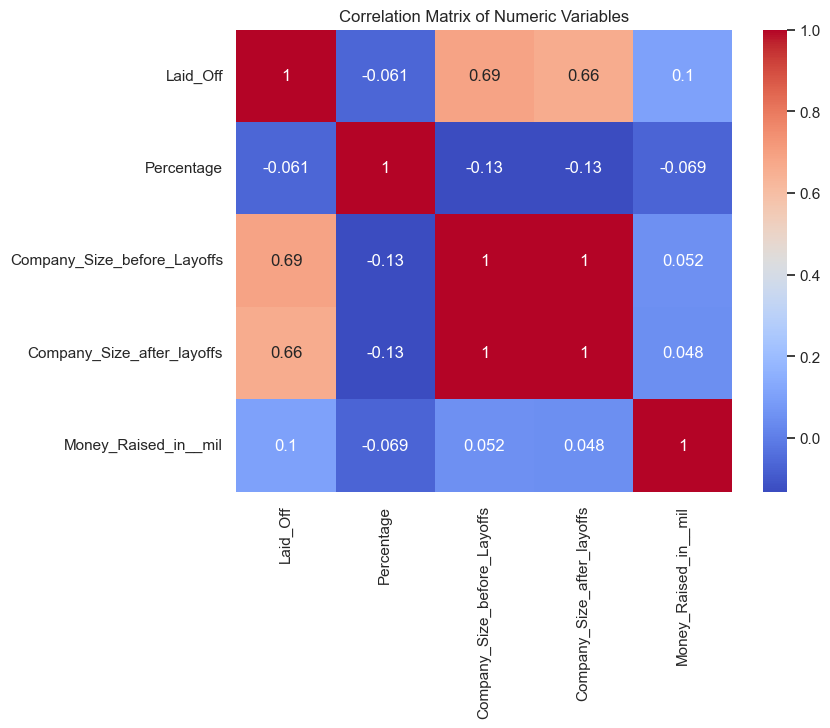

In [100]:
# build correlation matrix to evaluate how number of layoffs, company size, and funding are related
numeric_cols = [
    'Laid_Off',
    'Percentage',
    'Company_Size_before_Layoffs',
    'Company_Size_after_layoffs',
    'Money_Raised_in__mil'
]

corr = usa_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

The correlation matrix reveals:
* The **number of employees laid off is strongly correlated with company size before layoffs (0.69)**. This suggests that larger-sized companies tend to layoff a greater volume of employees. The observed pattern could reflect the company's larger number of employees. 
* The **percentage of layoffs shows little correlation with company size (-0.13)**. So while larger companies lay off a higher number of employees, smaller ones may experience a larger proportion of layoffs. 
* The **amount of money raised by a company shows weak correlation with layoffs (0.10)**. This suggests that company funding alone is not a strong predictor of layoffs. Perhaps, factors like market conditions and industry trends have stronger influence?

### 4. Visualizations (e.g., histograms, scatter plots, heatmaps)

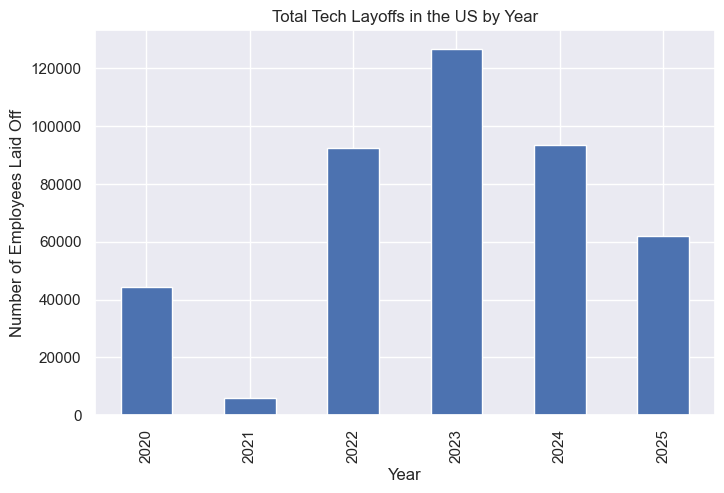

In [75]:
# layoffs over time
yearly_layoffs = usa_df.groupby('Year')['Laid_Off'].sum()

plt.figure(figsize=(8,5))
yearly_layoffs.plot(kind='bar')
plt.title("Total Tech Layoffs in the US by Year")
plt.ylabel("Number of Employees Laid Off")
plt.show()

The bar graph shows that layoffs were **lowest in 2021**, **increased significantly in 2022**, and **peaked in 2023**, coinciding with the COVID-19 pandemic.

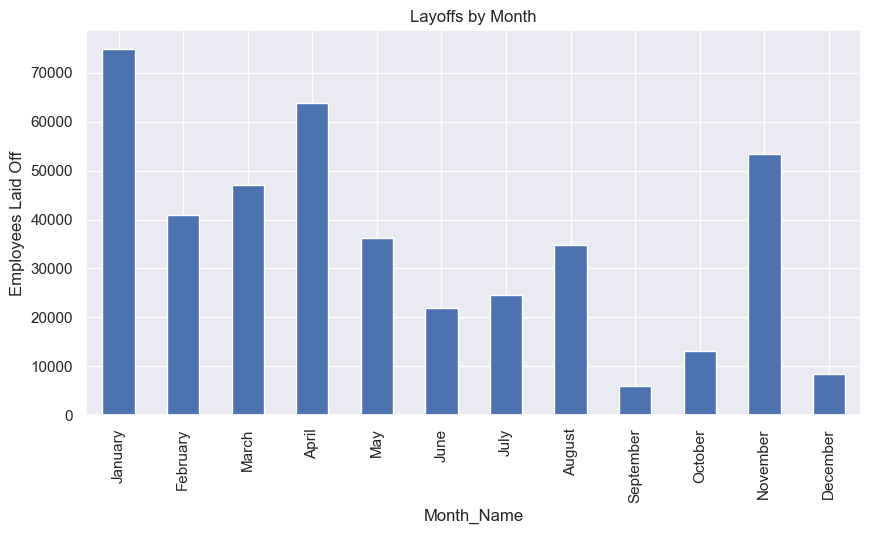

In [77]:
# monthly seasonality
monthly_layoffs = usa_df.groupby('Month_Name')['Laid_Off'].sum()

monthly_layoffs = monthly_layoffs.reindex(['January','February','March','April','May','June',
                                           'July','August','September','October','November','December'
                                          ])

plt.figure(figsize=(10,5))
monthly_layoffs.plot(kind='bar')
plt.title("Layoffs by Month")
plt.ylabel("Employees Laid Off")
plt.show()

Layoffs were **highest** in January, then April, then November, which may be due to financial planning.

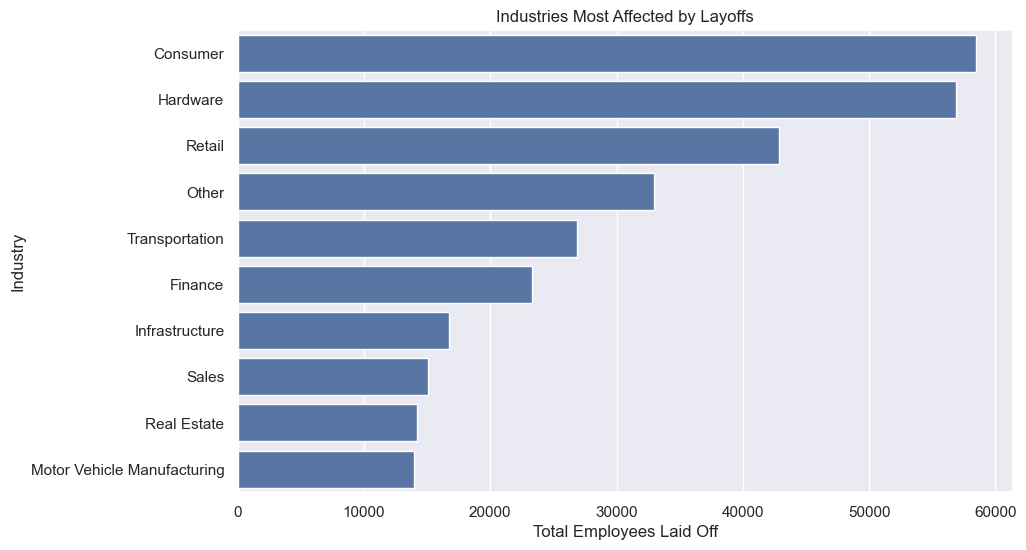

In [78]:
# industry impact
industry_layoffs = usa_df.groupby('Industry')['Laid_Off'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=industry_layoffs.values, y=industry_layoffs.index)
plt.title("Industries Most Affected by Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.show()

**Consumer** and **hardware tech** were most affected by layoffs. 

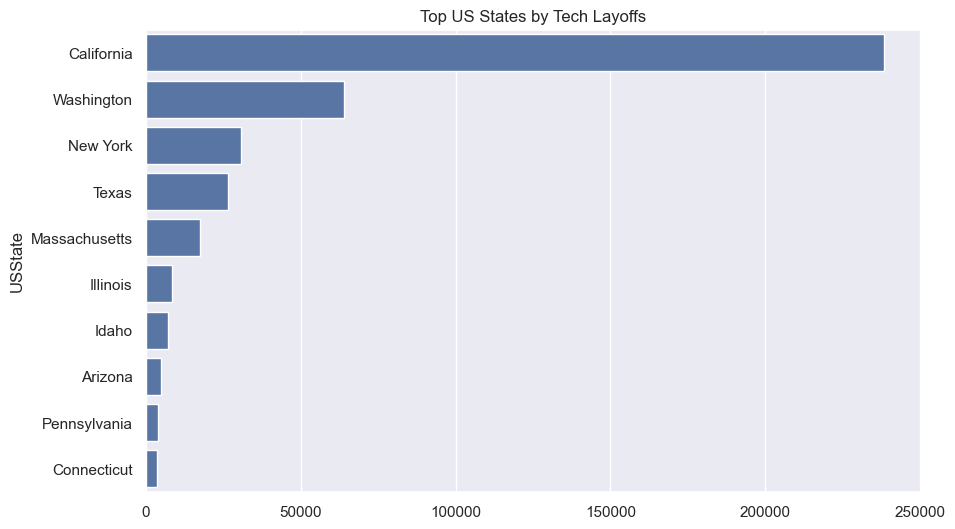

In [79]:
# comparing California to other states
state_layoffs = usa_df.groupby('USState')['Laid_Off'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=state_layoffs.values, y=state_layoffs.index)
plt.title("Top US States by Tech Layoffs")
plt.show()

Compared to the other states, **California** experienced **significantly more layoffs**, likely due to the high concentration of tech in Silicon Valley.

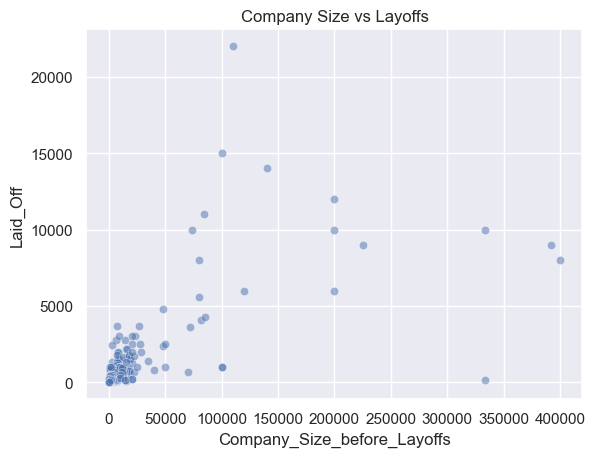

In [80]:
# company size effect
sns.scatterplot(
    data=usa_df,
    x='Company_Size_before_Layoffs',
    y='Laid_Off',
    alpha=0.5
)

plt.title("Company Size vs Layoffs")
plt.show()

**Larger-sized** companies were **more likely** to lay off a large number of employees, but there is variability here. 

### 5. Hypotheses formation to guide future analysis

1. Tech layoffs spiked significantly in 2022 and peaked in 2023, which likely reflects aggressive hiring during the pandemic and tried to reverse that post-pandemic. 
2. California experiences the highest number of layoffs due to high concentration of tech companies in the Silicon Valley.
3. Industries, like consumer tech, may experience higher layoff activity due to their sensitivity to market demand.
4. Larger companies may conduct layoffs that affect significantly more people, but smaller ones may experience larger proportional workforce cuts. 